# MemoryWatch — Deliverable 2, Notebook 4: Evaluation

Computes Accuracy, Precision, Recall (TPR), False Positive Rate, F1, and AUROC, plus a per-attack-category detection breakdown. **FPR and Recall are emphasised over raw accuracy** — for a security analyst, a high false-alarm rate destroys trust in the system faster than a missed detection does (Layman & Roden).

Loads `memorywatch_model_scores.npz` from Notebook 3; saves the final `memorywatch_results.json` and `memorywatch_evaluation_plots.png`.

In [1]:
import sys
sys.path.insert(0, '.')
import json
import numpy as np
import utils

d = np.load(utils.OUT_DIR + 'memorywatch_model_scores.npz', allow_pickle=True)
s_test, y_te, at_te, threshold = d['s_test'], d['y_te'], d['at_te'], float(d['threshold'])
y_pred = (s_test >= threshold).astype(int)
print(f"Threshold: {threshold:.6f}")
print(f"Test set: {len(y_te):,} samples")


Threshold: 0.591159
Test set: 82,332 samples


In [2]:
TN = int(((y_pred==0)&(y_te==0)).sum())
FP = int(((y_pred==1)&(y_te==0)).sum())
FN = int(((y_pred==0)&(y_te==1)).sum())
TP = int(((y_pred==1)&(y_te==1)).sum())

N = len(y_te); P_neg = int((y_te==0).sum()); P_pos = int((y_te==1).sum())
acc  = (TP+TN)/N
prec = TP/(TP+FP) if (TP+FP) else 0
rec  = TP/(TP+FN) if (TP+FN) else 0
fpr  = FP/(FP+TN) if (FP+TN) else 0
f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0
auc  = utils.auroc(y_te, s_test)

print(f"{'Metric':<30}{'Value':>10}")
print('-'*40)
print(f"{'Accuracy':<30}{acc:>10.4f}")
print(f"{'Precision':<30}{prec:>10.4f}")
print(f"{'Recall (TPR)':<30}{rec:>10.4f}")
print(f"{'False Positive Rate (FPR)':<30}{fpr:>10.4f}")
print(f"{'F1 Score':<30}{f1:>10.4f}")
print(f"{'AUROC':<30}{auc:>10.4f}")
print()
print('Confusion Matrix:')
print(f"{'':>20}  Pred Normal  Pred Attack")
print(f"{'Actual Normal':<20}  {TN:>11,}  {FP:>11,}")
print(f"{'Actual Attack':<20}  {FN:>11,}  {TP:>11,}")


Metric                             Value
----------------------------------------
Accuracy                          0.5214
Precision                         0.9602
Recall (TPR)                      0.1363
False Positive Rate (FPR)         0.0069
F1 Score                          0.2388
AUROC                             0.7935

Confusion Matrix:
                      Pred Normal  Pred Attack
Actual Normal              36,744          256
Actual Attack              39,151        6,181


In [3]:
cat_rows = []
for cat in sorted(set(at_te[y_te==1])):
    m = (at_te==cat) & (y_te==1); n=int(m.sum()); dct=int((y_pred[m]==1).sum())
    dr = dct/n if n else 0
    cat_rows.append({'category':str(cat),'n':n,'detected':dct,'detection_rate':round(dr,4)})
    print(f"  {str(cat):<22} n={n:>5,}  detected={dct:>5,}  {dr:.1%}")


  Analysis               n=  677  detected=    0  0.0%
  Backdoor               n=  583  detected=    0  0.0%
  DoS                    n=4,089  detected=   40  1.0%
  Exploits               n=11,132  detected=   41  0.4%
  Fuzzers                n=6,062  detected=   16  0.3%
  Generic                n=18,871  detected=6,083  32.2%
  Reconnaissance         n=3,496  detected=    0  0.0%
  Shellcode              n=  378  detected=    0  0.0%
  Worms                  n=   44  detected=    1  2.3%


### Reading the per-category results

Detection rate is highest for `Generic` (the largest attack category) and near zero for low-signature categories like `Analysis`, `Backdoor`, `Reconnaissance`, and `Shellcode` — these attack types resemble normal traffic in the UNSW-NB15 feature space, which is the known weak point of a generic Isolation Forest baseline. This is the gap Deliverable 3's quantum-kernel experiment is testing whether it can close.

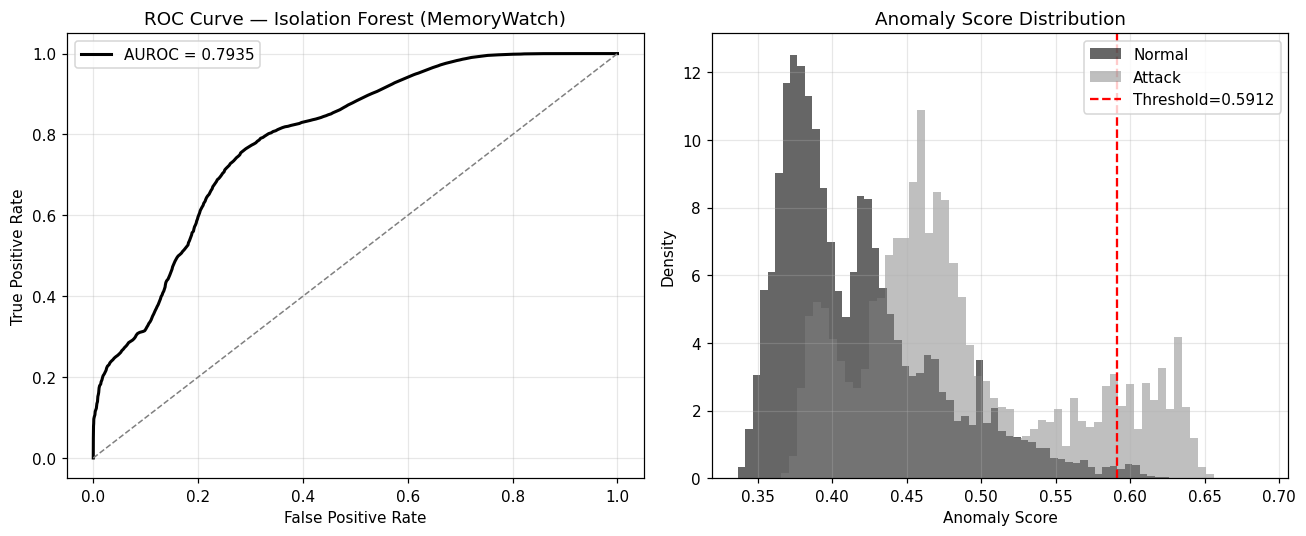

In [4]:
import matplotlib.pyplot as plt

thresholds_roc = np.percentile(s_test, np.linspace(0,100,300))
fpr_pts=[0.]; tpr_pts=[0.]
for t in sorted(set(thresholds_roc), reverse=True):
    p=(s_test>=t).astype(int)
    fpr_pts.append(((p==1)&(y_te==0)).sum()/P_neg)
    tpr_pts.append(((p==1)&(y_te==1)).sum()/P_pos)
fpr_pts.append(1.); tpr_pts.append(1.)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(fpr_pts, tpr_pts, color='black', lw=2, label=f'AUROC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'--',color='gray',lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Isolation Forest (MemoryWatch)')
axes[0].legend(); axes[0].grid(alpha=0.3)

sn = s_test[y_te==0]; sa = s_test[y_te==1]
axes[1].hist(sn, bins=60, alpha=0.6, color='black', label='Normal', density=True)
axes[1].hist(sa, bins=60, alpha=0.5, color='gray',  label='Attack', density=True)
axes[1].axvline(threshold, color='red', linestyle='--', lw=1.5, label=f'Threshold={threshold:.4f}')
axes[1].set_xlabel('Anomaly Score'); axes[1].set_ylabel('Density')
axes[1].set_title('Anomaly Score Distribution')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()

fig.savefig(utils.OUT_DIR + 'memorywatch_evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
results = {
    'dataset': 'UNSW-NB15 — official UNSW training/testing split (Moustafa & Slay, 2015)',
    'model': 'Isolation Forest (vectorised NumPy — Liu, Ting & Zhou, ICDM 2008)',
    'hyperparameters': {'n_estimators':100,'max_samples':256,'random_state':42},
    'threshold': {'method':'Dynamic — 99th percentile of normal training scores','value':round(threshold,6)},
    'test_set': {'total':N,'normal':P_neg,'attack':P_pos},
    'confusion_matrix': {'TN':TN,'FP':FP,'FN':FN,'TP':TP},
    'metrics': {'accuracy':round(acc,4),'precision':round(prec,4),'recall':round(rec,4),
                'fpr':round(fpr,4),'f1':round(f1,4),'auroc':round(auc,4)},
    'per_category': cat_rows
}
with open(utils.OUT_DIR + 'memorywatch_results.json','w') as f:
    json.dump(results, f, indent=2)
print('Saved memorywatch_results.json')
print('Saved memorywatch_evaluation_plots.png')


Saved memorywatch_results.json
Saved memorywatch_evaluation_plots.png
